In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from Ranking_exp import Ranking_exp

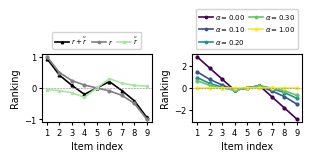

In [40]:
import contextlib, io
from matplotlib import cm

FIG_W_IN     = 325.48499 / 72.27  # NeurIPS column width ≈ 4.504 in
FIG_W_IN_now = (2 / 3) * FIG_W_IN

n     = 9
p     = 6
q     = 4
k_s   = 1.0
k_d   = 0.0
c_reg = 1e10
x     = np.arange(1, n + 1)

def fmt_ax(ax):
    ax.axhline(0, color='gray', lw=0.4, ls='--')
    ax.set_xticks(x)
    ax.set_xticklabels([str(k) for k in x], fontsize=6)
    ax.set_xlabel('Item index', fontsize=7, labelpad=3)
    ax.set_ylabel('Ranking', fontsize=7, labelpad=3)
    ax.tick_params(axis='both', length=2, pad=2, labelsize=6)

alphas = [1e-10, 0.1, 0.2, 0.3, 0.9999999999999]
colors = cm.viridis(np.linspace(0, 1, len(alphas)))

alpha_b = 0.2
k_o_b   = ((1 - alpha_b) / 2) * (k_s - k_d)
with contextlib.redirect_stdout(io.StringIO()):
    sim_b = Ranking_exp(n=n, k_o=k_o_b, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=c_reg)
rank_original     = sim_b.calc_rank_original()
rank_perturbative = sim_b.calc_rank_perturbative()
rank_new          = sim_b.calc_rank_analytic()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(FIG_W_IN_now, 1.5), layout='constrained')

ax1.plot(x, rank_new, marker='^', markersize=2, lw=1.2, color='black',
         label=rf'$r + \tilde{{r}}$')
ax1.plot(x, rank_original, marker='o', markersize=2, lw=1.2, color='gray',
         label=rf'$r$')
ax1.plot(x, rank_perturbative, marker='s', markersize=2, lw=1.2, color='#A8E6A3',
         label=rf'$\tilde{{r}}$')
fmt_ax(ax1)
ax1.legend(fontsize=5, loc='lower center', bbox_to_anchor=(0.5, 1.02),
           ncol=3, framealpha=0.85, columnspacing=0.6,
           handletextpad=0.3, markerscale=0.85)

for a, color in zip(alphas, colors):
    k_o_a = ((1 - a) / 2) * (k_s - k_d)
    with contextlib.redirect_stdout(io.StringIO()):
        sim_a = Ranking_exp(n=n, k_o=k_o_a, k_s=k_s, k_d=k_d,
                            p=p, q=q, c_reg=c_reg)
    r = sim_a.calc_rank()
    ax2.plot(x, r, marker='o', markersize=2, lw=1.2, color=color,
             label=rf'$\alpha = {a:.2f}$')
fmt_ax(ax2)
ax2.legend(fontsize=5, loc='lower center', bbox_to_anchor=(0.5, 1.02),
           ncol=2, framealpha=0.85, columnspacing=0.6,
           handletextpad=0.3, markerscale=0.85)

plt.show()
fig.savefig("Figure_2.pdf", bbox_inches="tight")


# Figures Together

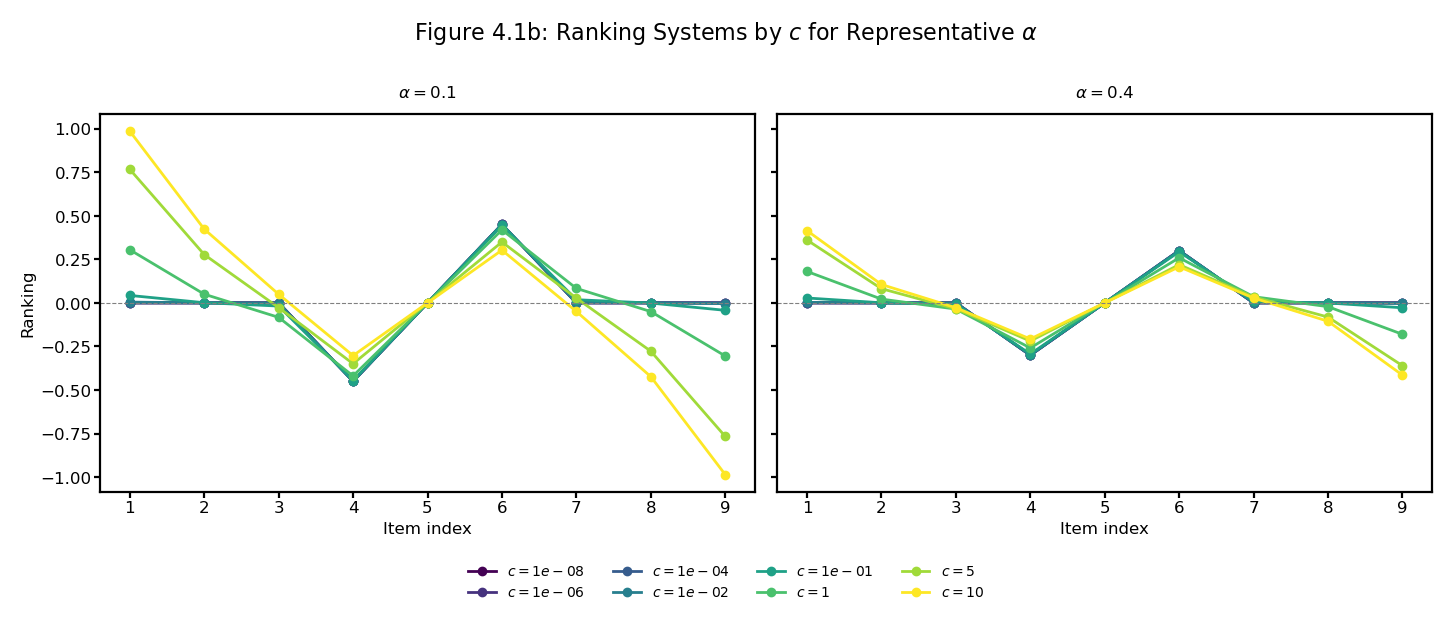

In [ ]:
import contextlib, io

n     = 9
p     = 6
q     = 4
k_s   = 1.0
k_d   = 0.0

eps = 1e-10

c_values = [1e-8, 1e-6, 1e-4, 1e-2, 1e-1, 1, 5, 10]
alphas_rep = [0.1, 0.4, 0.8]

x = np.arange(1, n + 1)

cmap = plt.cm.viridis
colors = [cmap(i / (len(c_values) - 1)) for i in range(len(c_values))]

with plt.rc_context({'figure.dpi': 200}):
    fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.6), sharey=True)

    for ax, alpha in zip(axes, alphas_rep):
        k_o_a = ((1 - alpha) / 2) * (k_s - k_d)

        for c_reg, color in zip(c_values, colors):
            with contextlib.redirect_stdout(io.StringIO()):
                sim = Ranking_exp(n=n, k_o=k_o_a, k_s=k_s, k_d=k_d,
                                  p=p, q=q, c_reg=c_reg)
            r = sim.calc_rank()
            label = f'$c = {c_reg:.0e}$' if c_reg < 1 else f'$c = {c_reg:g}$'
            ax.plot(x, r, marker='o', markersize=2.5, lw=1.0, color=color, label=label)

        ax.axhline(0, color='gray', lw=0.4, ls='--')
        ax.set_xticks(x)
        ax.set_xticklabels([str(k) for k in x], fontsize=6)
        ax.set_xlabel('Item index', fontsize=6, labelpad=2)
        ax.set_title(rf'$\alpha = {alpha}$', fontsize=6)
        ax.tick_params(axis='both', length=2, pad=1, labelsize=6)

    axes[0].set_ylabel('Ranking', fontsize=6, labelpad=2)

    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=5,
               frameon=False, bbox_to_anchor=(0.5, -0.12))

    fig.suptitle('Figure 4.1b: Ranking Systems by $c$ for Representative $\\alpha$',
                 fontsize=8, y=1.02)
    plt.tight_layout(pad=0.5, w_pad=0.6)
    plt.show()

In [ ]:
import contextlib, io

n     = 9
p     = 6
q     = 4
k_s   = 1.0
k_d   = 0.0
c_reg = 1e10

alpha = 0.4
k_o_a = ((1 - alpha) / 2) * (k_s - k_d)

with contextlib.redirect_stdout(io.StringIO()):
    sim = Ranking_exp(n=n, k_o=k_o_a, k_s=k_s, k_d=k_d,
                      p=p, q=q, c_reg=c_reg)

r_original     = sim.calc_rank_original()
r_perturbative = sim.calc_rank_perturbative()
r_analytic     = sim.calc_rank_analytic()

x = np.arange(1, n + 1)

with plt.rc_context({'figure.dpi': 100}):
    fig, ax = plt.subplots(1, 1, figsize=(4.0, 2.8))

    ax.plot(x, r_original,     marker='o', markersize=3, lw=1.2, color='tab:blue',
            label=r'$r^{(0)}$ (original)')
    ax.plot(x, r_perturbative, marker='s', markersize=3, lw=1.2, color='tab:orange',
            label=r'$\tilde{r}$ (perturbative)')
    ax.plot(x, r_analytic,     marker='^', markersize=3, lw=1.2, color='tab:green',
            label=r'$r^{(0)} + \tilde{r}$ (analytic)')

    ax.axhline(0, color='gray', lw=0.4, ls='--')
    ax.set_xticks(x)
    ax.set_xticklabels([str(k) for k in x], fontsize=7)
    ax.set_xlabel('Item index', fontsize=8, labelpad=3)
    ax.set_ylabel('Ranking', fontsize=8, labelpad=3)
    ax.set_title(rf'Decomposition: original + perturbative ($\alpha={alpha}$)', fontsize=9)
    ax.tick_params(axis='both', length=2, pad=2, labelsize=7)
    ax.legend(fontsize=6, loc='best', framealpha=0.9)

    plt.tight_layout(pad=0.5)
    plt.show()

NameError: name 'Ranking_exp' is not defined